# Notebook 04: Ridge Regression RF Reconstruction — Single Container Test

Tests the new **ridge regression** implementation in `src/rf_analysis/sparse_noise.py`
against the previous STA-based results on container **661732156** (highest yield in batch:
130/189 neurons passed R² ≥ 0.3 with STA).

## What we check
1. Single-neuron walkthrough — spatiotemporal RF across all lags, best lag selection
2. Side-by-side RF maps: ridge vs STA for the same neurons
3. Full container run with ridge → yield and parameter distributions
4. Yield comparison: ridge vs STA
5. RF gallery sorted by κ (ridge results)

**Container:** 661732156 · **Experiment:** 661753184 · **Cre:** Slc17a7-IRES2-Cre · **Depth:** 175 µm

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
import seaborn as sns
from scipy.stats import pearsonr
from allensdk.core.brain_observatory_cache import BrainObservatoryCache
import sys, os, warnings, time
from pathlib import Path

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.sparse_noise import (
    reconstruct_rf, fit_gaussian_derivative, extract_spatial_parameters, gaussian_2d
)

plt.style.use('seaborn-v0_8-darkgrid')
warnings.filterwarnings('ignore')
%matplotlib inline

BASE_DIR   = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
CACHE_DIR  = BASE_DIR / 'data' / 'cache'
LISTS_DIR  = BASE_DIR / 'data' / 'experiment_lists'
OUT_DIR    = BASE_DIR / 'outputs' / 'rf_params'

boc = BrainObservatoryCache(manifest_file=str(CACHE_DIR / 'manifest.json'))

CONTAINER_ID = 661732156
EXP_ID       = 661753184
QUALITY_THRESHOLD = 0.3

dataset  = boc.get_ophys_experiment_data(EXP_ID)
cell_ids = dataset.get_cell_specimen_ids()
print(f'Container {CONTAINER_ID}  |  exp {EXP_ID}')
print(f'Neurons: {len(cell_ids)}')

Container 661732156  |  exp 661753184
Neurons: 189


---
## 1. Single-neuron walkthrough

Run ridge on the first neuron. Show:
- Spatiotemporal RF across all 8 lags (the regression weights reshaped)
- Lag energy profile → best lag selection
- ON / OFF subfields at best lag
- Gaussian fit overlay

In [3]:
# Use first neuron that converges — try a few if needed
DEMO_CELL = cell_ids[0]

rf_on, rf_off, meta = reconstruct_rf(dataset, DEMO_CELL)
params, quality = fit_gaussian_derivative(rf_on, rf_off, pixel_size_deg=meta['pixel_size_deg'])

print('Metadata:')
for k, v in meta.items():
    print(f'  {k}: {v}')
print(f'\nR² = {quality["r_squared"]:.3f}  |  converged: {quality["converged"]}')
print(f'sigma={params["sigma"]:.2f}°  kappa={params["kappa"]:.2f}  theta={params["theta"]:.1f}°')

Metadata:
  grid_size: (16, 28)
  pixel_size_deg: 4.65
  stim_name: locally_sparse_noise_4deg
  cell_id: 673450046
  n_presentations: 5812
  response_delay: 4
  response_window: 5
  method: ridge
  n_lags: 8
  best_lag: 1
  best_lag_ms: 266.7
  ridge_lambda: 13335.21432163324
  cv_folds: 5

R² = 0.019  |  converged: True
sigma=13.17°  kappa=7.98  theta=74.7°


In [4]:
# --- Spatiotemporal RF: re-run reconstruction to get full STRF ---
# We need to dig into the design matrix to recover all lags.
# Easiest: call reconstruct_rf with n_lags and read from strf directly.
# Since reconstruct_rf doesn't expose strf, we replicate the key steps here for viz.

from sklearn.linear_model import RidgeCV

N_LAGS = 8
RESPONSE_DELAY  = 4
RESPONSE_WINDOW = 5

stim_table = dataset.get_stimulus_table('locally_sparse_noise_4deg')
template_result = dataset.get_locally_sparse_noise_stimulus_template(stimulus='locally_sparse_noise_4deg')
template = template_result[0] if isinstance(template_result, tuple) else template_result
n_template_frames, grid_h, grid_w = template.shape
on_val, off_val = int(template.max()), int(template.min())

_, dff = dataset.get_dff_traces(cell_specimen_ids=[DEMO_CELL])
dff = dff[0]
n_tp = len(dff)

starts        = stim_table['start'].values.astype(int)
frame_indices = stim_table['frame'].values.astype(int)
n_pres        = len(starts)

win_idx   = (starts + RESPONSE_DELAY)[:, None] + np.arange(RESPONSE_WINDOW)
valid_win = (win_idx >= 0) & (win_idx < n_tp)
win_safe  = np.clip(win_idx, 0, n_tp - 1)
dff_win   = dff[win_safe]
dff_win[~valid_win] = np.nan
responses = np.nanmean(dff_win, axis=1)

valid = ~np.isnan(responses) & (frame_indices >= 0) & (frame_indices < n_template_frames)

n_pixels = grid_h * grid_w
stim_enc = np.zeros((n_pres, n_pixels), dtype=np.float32)
for p in np.where((frame_indices >= 0) & (frame_indices < n_template_frames))[0]:
    f = template[frame_indices[p]].ravel().astype(np.float32)
    stim_enc[p, f == on_val]  =  1.0
    stim_enc[p, f == off_val] = -1.0

X = np.zeros((n_pres, n_pixels * N_LAGS), dtype=np.float32)
for lag in range(N_LAGS):
    n_v = n_pres - lag
    if n_v > 0:
        X[lag:, lag*n_pixels:(lag+1)*n_pixels] = stim_enc[:n_v]

ridge = RidgeCV(alphas=np.logspace(-2, 5, 25), cv=5, fit_intercept=True)
ridge.fit(X[valid], responses[valid])

strf = ridge.coef_.reshape(N_LAGS, grid_h, grid_w)
lag_energy = np.array([np.abs(strf[l]).max() for l in range(N_LAGS)])
best_lag   = int(np.argmax(lag_energy))
print(f'Best lag: {best_lag}  |  λ selected: {ridge.alpha_:.3g}  |  n_valid_pres: {valid.sum()}')

Best lag: 1  |  λ selected: 1.33e+04  |  n_valid_pres: 5812


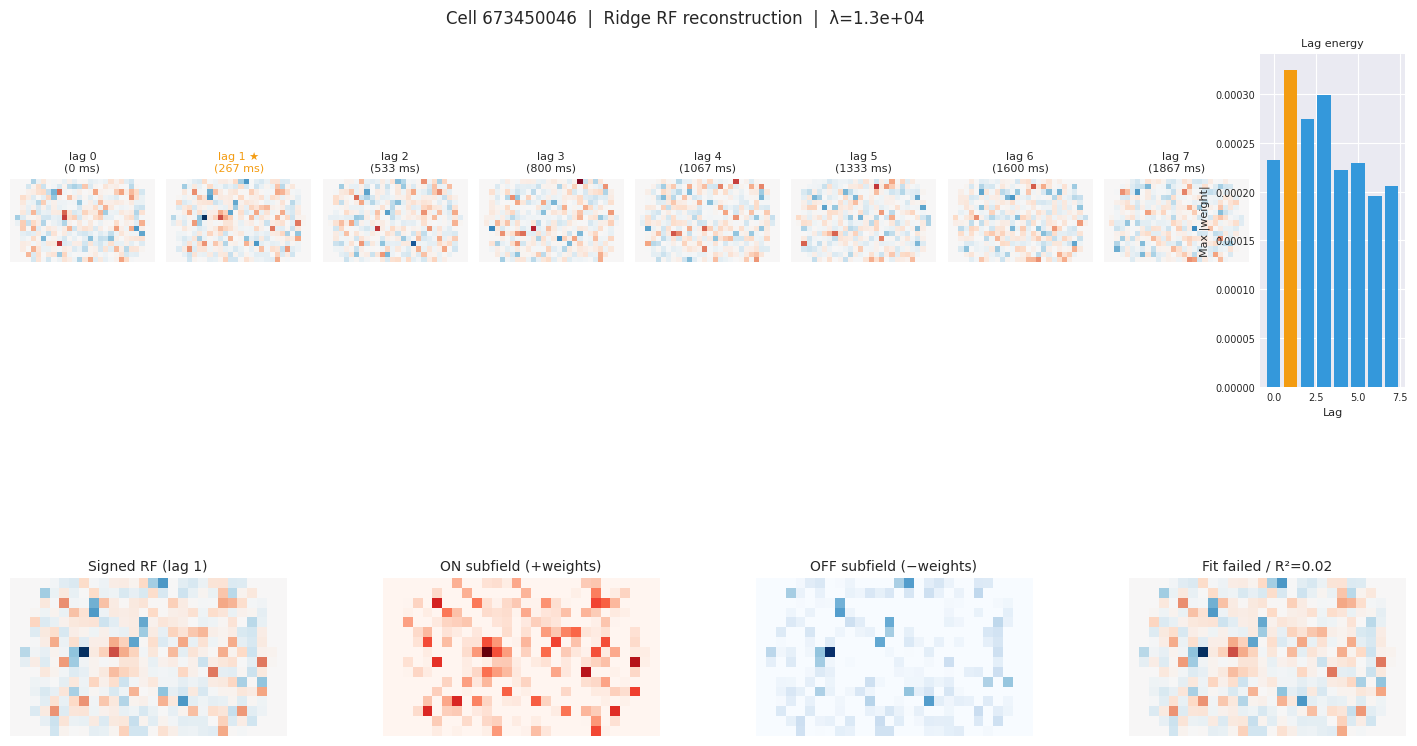

In [5]:
# --- Plot: spatiotemporal RF across all lags + lag energy + ON/OFF + fit ---

vmax_strf = np.abs(strf).max()
diffs     = np.diff(starts[:100])
ms_per_lag = float(np.median(diffs[diffs > 0])) * (1000 / 30)

fig = plt.figure(figsize=(18, 9))
gs_top = gridspec.GridSpec(1, N_LAGS + 1, figure=fig,
                            top=0.92, bottom=0.55, wspace=0.08)
gs_bot = gridspec.GridSpec(1, 4, figure=fig,
                            top=0.45, bottom=0.05, wspace=0.35)

# Top row: STRF lags
for lag in range(N_LAGS):
    ax = fig.add_subplot(gs_top[0, lag])
    ax.imshow(strf[lag], cmap='RdBu_r', vmin=-vmax_strf, vmax=vmax_strf,
              origin='upper', aspect='equal')
    lag_ms = lag * ms_per_lag
    ax.set_title(f'lag {lag}\n({lag_ms:.0f} ms)', fontsize=8)
    ax.axis('off')
    if lag == best_lag:
        for spine in ax.spines.values():
            spine.set_edgecolor('#f39c12')
            spine.set_linewidth(3)
        ax.set_title(f'lag {lag} ★\n({lag_ms:.0f} ms)', fontsize=8, color='#f39c12')

# Top-right: lag energy
ax_e = fig.add_subplot(gs_top[0, N_LAGS])
ax_e.bar(range(N_LAGS), lag_energy,
         color=['#f39c12' if l == best_lag else '#3498db' for l in range(N_LAGS)])
ax_e.set_xlabel('Lag', fontsize=8)
ax_e.set_ylabel('Max |weight|', fontsize=8)
ax_e.set_title('Lag energy', fontsize=8)
ax_e.tick_params(labelsize=7)

# Bottom: signed RF | ON | OFF | Gaussian fit
rf_map = strf[best_lag]
vmax_rf = np.abs(rf_map).max()

ax0 = fig.add_subplot(gs_bot[0, 0])
ax0.imshow(rf_map, cmap='RdBu_r', vmin=-vmax_rf, vmax=vmax_rf,
           origin='upper', aspect='equal')
ax0.set_title(f'Signed RF (lag {best_lag})', fontsize=10)
ax0.axis('off')

ax1 = fig.add_subplot(gs_bot[0, 1])
ax1.imshow(np.maximum(rf_map, 0), cmap='Reds', origin='upper', aspect='equal')
ax1.set_title('ON subfield (+weights)', fontsize=10)
ax1.axis('off')

ax2 = fig.add_subplot(gs_bot[0, 2])
ax2.imshow(np.maximum(-rf_map, 0), cmap='Blues', origin='upper', aspect='equal')
ax2.set_title('OFF subfield (−weights)', fontsize=10)
ax2.axis('off')

# Gaussian fit overlay on signed map
ax3 = fig.add_subplot(gs_bot[0, 3])
ax3.imshow(rf_map, cmap='RdBu_r', vmin=-vmax_rf, vmax=vmax_rf,
           origin='upper', aspect='equal')
pix = meta['pixel_size_deg']
if quality['converged'] and quality['r_squared'] >= QUALITY_THRESHOLD:
    ell = Ellipse(xy=(params['x0']/pix, params['y0']/pix),
                  width=2*params['sigma_x']/pix, height=2*params['sigma_y']/pix,
                  angle=params['theta'],
                  edgecolor='yellow', facecolor='none', linewidth=2, linestyle='--')
    ax3.add_patch(ell)
    ax3.set_title(f'Gaussian fit\nσ={params["sigma"]:.1f}° κ={params["kappa"]:.2f} R²={quality["r_squared"]:.2f}',
                  fontsize=10)
else:
    ax3.set_title(f'Fit failed / R²={quality["r_squared"]:.2f}', fontsize=10)
ax3.axis('off')

fig.suptitle(f'Cell {DEMO_CELL}  |  Ridge RF reconstruction  |  λ={ridge.alpha_:.2g}',
             fontsize=12, y=0.97)
plt.savefig(OUT_DIR / f'fig_ridge_demo_cell_{DEMO_CELL}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Ridge vs STA: side-by-side for 6 example neurons

Load the saved STA results for this container, pick neurons that were
fitted by STA, and run ridge on the same cells.

In [6]:
sta_df = pd.read_csv(OUT_DIR / f'rf_params_container_{CONTAINER_ID}.csv')
print(f'STA results: {len(sta_df)} neurons fitted')

# Pick 6 neurons spanning the R² range from STA
sta_sorted = sta_df.sort_values('r_squared').reset_index(drop=True)
pick_idx   = np.linspace(0, len(sta_sorted) - 1, 6).astype(int)
compare_cells = sta_sorted.iloc[pick_idx]['cell_id'].tolist()
print(f'Comparing cells: {compare_cells}')
print(sta_sorted.iloc[pick_idx][['cell_id', 'r_squared', 'sigma', 'kappa']].to_string(index=False))

STA results: 130 neurons fitted
Comparing cells: [673451250, 673449814, 673449391, 673448464, 673449355, 673450235]
  cell_id  r_squared    sigma    kappa
673451250   0.302943 7.720877 2.314015
673449814   0.418119 7.496495 2.284235
673449391   0.515843 7.465619 1.315387
673448464   0.638316 6.152250 1.557438
673449355   0.710696 6.198732 1.967179
673450235   0.881305 8.300726 2.244976


In [7]:
# Run ridge on the 6 comparison cells
ridge_compare = {}
for cid in compare_cells:
    try:
        ro, roff, rmeta = reconstruct_rf(dataset, int(cid))
        rp, rq = fit_gaussian_derivative(ro, roff, pixel_size_deg=rmeta['pixel_size_deg'])
        ridge_compare[cid] = {'rf_on': ro, 'rf_off': roff, 'params': rp, 'quality': rq, 'meta': rmeta}
    except Exception as e:
        print(f'Cell {cid}: {e}')

print(f'Ridge fitted: {len(ridge_compare)}/6 cells')

Ridge fitted: 6/6 cells


In [8]:
# Side-by-side: STA RF (on-off) vs Ridge RF for 6 neurons
# We need to re-run STA manually for comparison. Use the old response_delay=4, window=7 averaging.

def reconstruct_rf_sta(dataset, cell_id, stimulus_name='locally_sparse_noise_4deg',
                        response_delay=4, response_window=7):
    """Minimal STA reconstruction for comparison."""
    stim_table = dataset.get_stimulus_table(stimulus_name)
    tr = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stimulus_name)
    template = tr[0] if isinstance(tr, tuple) else tr
    n_tf, gh, gw = template.shape
    on_v, off_v  = int(template.max()), int(template.min())

    _, dff = dataset.get_dff_traces(cell_specimen_ids=[cell_id])
    dff = dff[0]
    n_tp = len(dff)

    starts = stim_table['start'].values.astype(int)
    fidx   = stim_table['frame'].values.astype(int)
    n_p    = len(starts)

    win_idx = (starts + response_delay)[:, None] + np.arange(response_window)
    valid   = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_win = dff[win_safe]
    dff_win[~valid] = np.nan
    responses = np.nanmean(dff_win, axis=1)

    keep = ~np.isnan(responses) & (fidx >= 0) & (fidx < n_tf)
    responses = responses[keep]
    fidx_k   = fidx[keep]

    shown      = template[fidx_k]
    on_mask    = (shown == on_v)
    off_mask   = (shown == off_v)
    resp_3d    = responses[:, None, None]
    counts_on  = on_mask.sum(axis=0).astype(float)
    counts_off = off_mask.sum(axis=0).astype(float)

    rf_on  = np.zeros((gh, gw))
    rf_off = np.zeros((gh, gw))
    np.divide((on_mask * resp_3d).sum(axis=0), counts_on,
              where=counts_on > 0, out=rf_on)
    np.divide((off_mask * resp_3d).sum(axis=0), counts_off,
              where=counts_off > 0, out=rf_off)
    return rf_on, rf_off

sta_rfs = {}
for cid in compare_cells:
    try:
        on, off = reconstruct_rf_sta(dataset, int(cid))
        sta_rfs[cid] = (on, off)
    except Exception as e:
        print(f'STA cell {cid}: {e}')

print(f'STA RFs recomputed for {len(sta_rfs)} cells')

STA RFs recomputed for 6 cells


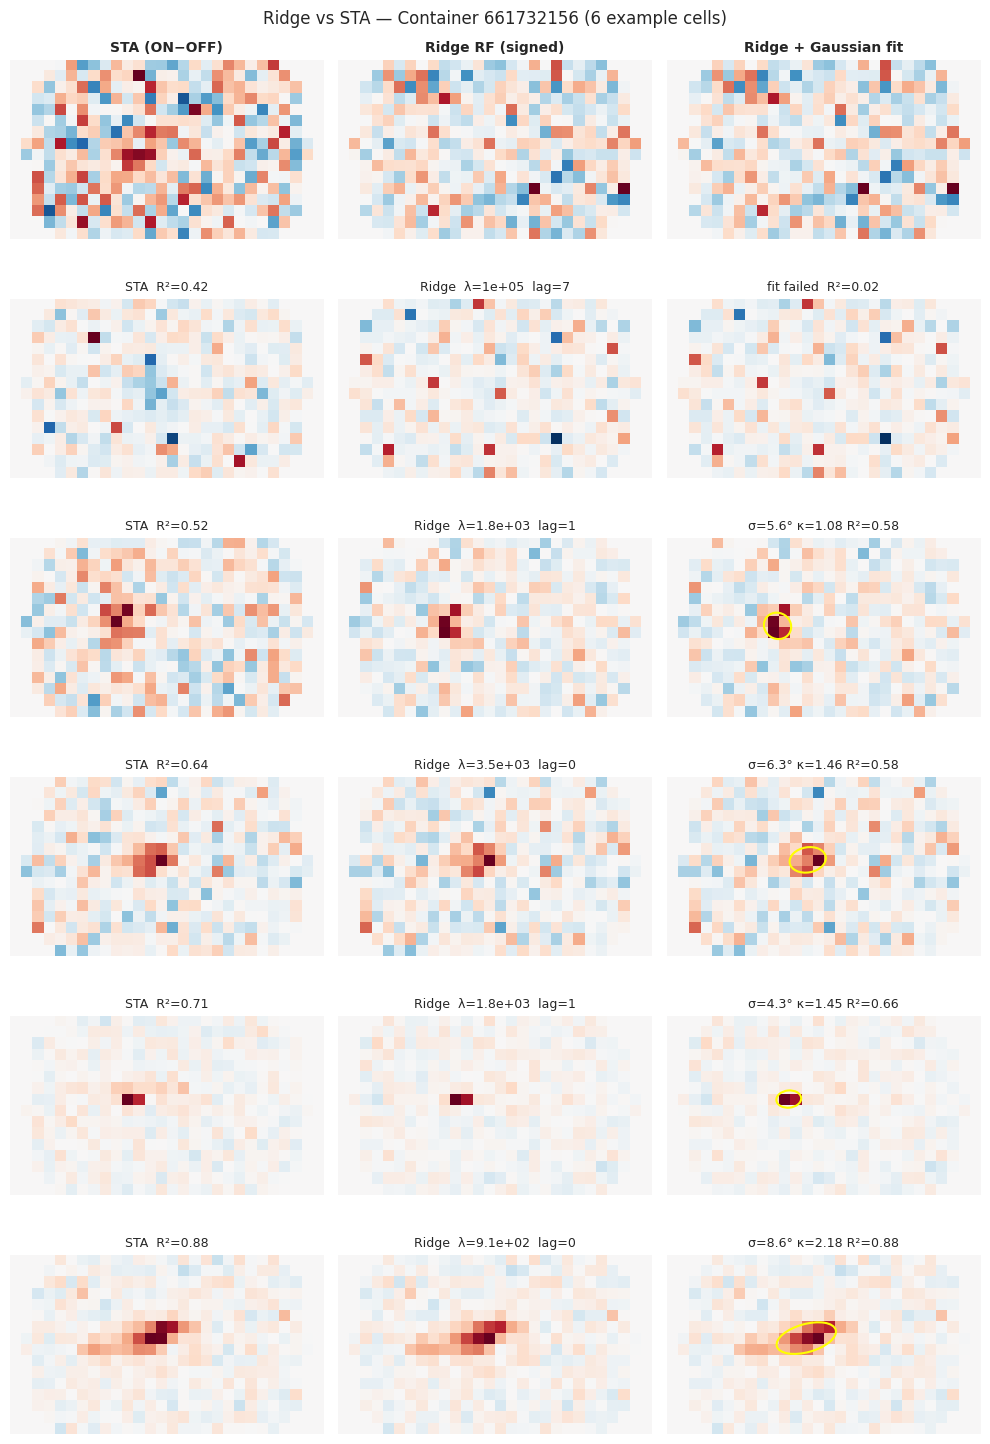

In [9]:
# Plot: 6 rows × 3 columns (STA map | Ridge map | Ridge fit)
n_cells = len(compare_cells)
fig, axes = plt.subplots(n_cells, 3, figsize=(10, n_cells * 2.5))

for row, cid in enumerate(compare_cells):
    # --- STA combined ---
    ax_sta = axes[row, 0]
    if cid in sta_rfs:
        sta_map = sta_rfs[cid][0] - sta_rfs[cid][1]
        vm = np.abs(sta_map).max() or 1e-9
        ax_sta.imshow(sta_map, cmap='RdBu_r', vmin=-vm, vmax=vm,
                      origin='upper', aspect='equal')
        sta_row = sta_df[sta_df['cell_id'] == cid]
        r2_sta  = sta_row['r_squared'].values[0] if len(sta_row) else float('nan')
        ax_sta.set_title(f'STA  R²={r2_sta:.2f}', fontsize=9)
    else:
        ax_sta.text(0.5, 0.5, 'no STA', ha='center', va='center', transform=ax_sta.transAxes)
    ax_sta.axis('off')
    ax_sta.set_ylabel(f'cell {cid}', fontsize=8)

    # --- Ridge signed RF ---
    ax_rid = axes[row, 1]
    if cid in ridge_compare:
        rc = ridge_compare[cid]
        rid_map = rc['rf_on'] - rc['rf_off']
        vm2 = np.abs(rid_map).max() or 1e-9
        ax_rid.imshow(rid_map, cmap='RdBu_r', vmin=-vm2, vmax=vm2,
                      origin='upper', aspect='equal')
        lam = rc['meta']['ridge_lambda']
        bl  = rc['meta']['best_lag']
        ax_rid.set_title(f'Ridge  λ={lam:.2g}  lag={bl}', fontsize=9)
    else:
        ax_rid.text(0.5, 0.5, 'ridge failed', ha='center', va='center', transform=ax_rid.transAxes)
    ax_rid.axis('off')

    # --- Ridge + Gaussian fit ---
    ax_fit = axes[row, 2]
    if cid in ridge_compare:
        rc = ridge_compare[cid]
        rid_map = rc['rf_on'] - rc['rf_off']
        vm3 = np.abs(rid_map).max() or 1e-9
        ax_fit.imshow(rid_map, cmap='RdBu_r', vmin=-vm3, vmax=vm3,
                      origin='upper', aspect='equal')
        rp, rq = rc['params'], rc['quality']
        if rq['converged'] and rq['r_squared'] >= QUALITY_THRESHOLD:
            pix = rc['meta']['pixel_size_deg']
            ell = Ellipse(xy=(rp['x0']/pix, rp['y0']/pix),
                          width=2*rp['sigma_x']/pix, height=2*rp['sigma_y']/pix,
                          angle=rp['theta'],
                          edgecolor='yellow', facecolor='none', linewidth=1.5)
            ax_fit.add_patch(ell)
            ax_fit.set_title(f'σ={rp["sigma"]:.1f}° κ={rp["kappa"]:.2f} R²={rq["r_squared"]:.2f}',
                              fontsize=9)
        else:
            ax_fit.set_title(f'fit failed  R²={rq["r_squared"]:.2f}', fontsize=9)
    ax_fit.axis('off')

    if row == 0:
        axes[row, 0].set_title('STA (ON−OFF)', fontsize=10, fontweight='bold')
        axes[row, 1].set_title('Ridge RF (signed)', fontsize=10, fontweight='bold')
        axes[row, 2].set_title('Ridge + Gaussian fit', fontsize=10, fontweight='bold')

fig.suptitle(f'Ridge vs STA — Container {CONTAINER_ID} (6 example cells)', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_ridge_vs_sta_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Full container run with ridge

Process all neurons in the container with the new method.

In [10]:
results_ridge = []
n_fail = 0
t0 = time.time()

for j, cid in enumerate(cell_ids):
    if (j + 1) % 20 == 0:
        elapsed = time.time() - t0
        rate    = (j + 1) / elapsed
        eta     = (len(cell_ids) - j - 1) / rate
        print(f'  {j+1}/{len(cell_ids)}  |  {rate:.1f} neurons/s  |  ETA {eta:.0f}s')

    result = extract_spatial_parameters(dataset, cid, quality_threshold=QUALITY_THRESHOLD)
    if result is not None:
        result['cell_id'] = cid
        results_ridge.append(result)
    else:
        n_fail += 1

ridge_df = pd.DataFrame(results_ridge)
elapsed  = time.time() - t0

print(f'\nDone in {elapsed:.0f}s')
print(f'Ridge yield: {len(ridge_df)}/{len(cell_ids)} neurons ({100*len(ridge_df)/len(cell_ids):.1f}%)')
print(f'STA yield:   {len(sta_df)}/{len(cell_ids)} neurons ({100*len(sta_df)/len(cell_ids):.1f}%)')

ridge_df.to_csv(OUT_DIR / f'rf_params_ridge_container_{CONTAINER_ID}.csv', index=False)
print(f'Saved: rf_params_ridge_container_{CONTAINER_ID}.csv')

  20/189  |  0.0 neurons/s  |  ETA 39868s
  40/189  |  0.0 neurons/s  |  ETA 33344s
  60/189  |  0.0 neurons/s  |  ETA 27481s
  80/189  |  0.0 neurons/s  |  ETA 22593s
  100/189  |  0.0 neurons/s  |  ETA 18178s
  120/189  |  0.0 neurons/s  |  ETA 13933s
  140/189  |  0.0 neurons/s  |  ETA 9945s
  160/189  |  0.0 neurons/s  |  ETA 6155s
  180/189  |  0.0 neurons/s  |  ETA 1979s

Done in 41738s
Ridge yield: 116/189 neurons (61.4%)
STA yield:   130/189 neurons (68.8%)
Saved: rf_params_ridge_container_661732156.csv


---
## 4. Yield and parameter comparison: ridge vs STA

In [11]:
# Neurons in both methods (intersection by cell_id)
both_ids = set(ridge_df['cell_id'].tolist()) & set(sta_df['cell_id'].tolist())
ridge_both = ridge_df[ridge_df['cell_id'].isin(both_ids)].set_index('cell_id')
sta_both   = sta_df[sta_df['cell_id'].isin(both_ids)].set_index('cell_id')

print(f'Neurons fitted by both methods: {len(both_ids)}')
print(f'Only ridge: {len(ridge_df) - len(both_ids)}')
print(f'Only STA:   {len(sta_df) - len(both_ids)}')
print()
print('Parameter comparison (neurons in both):')
for param in ['sigma', 'kappa', 'theta', 'r_squared']:
    r_vals = ridge_both[param].dropna()
    s_vals = sta_both[param].dropna()
    print(f'  {param:12s}: ridge {r_vals.mean():.3f} ± {r_vals.std():.3f}  |  '
          f'STA {s_vals.mean():.3f} ± {s_vals.std():.3f}')

Neurons fitted by both methods: 109
Only ridge: 7
Only STA:   21

Parameter comparison (neurons in both):
  sigma       : ridge 6.678 ± 1.651  |  STA 6.699 ± 1.534
  kappa       : ridge 1.742 ± 0.727  |  STA 1.800 ± 0.731
  theta       : ridge 88.068 ± 78.665  |  STA 111.274 ± 78.666
  r_squared   : ridge 0.573 ± 0.150  |  STA 0.603 ± 0.146


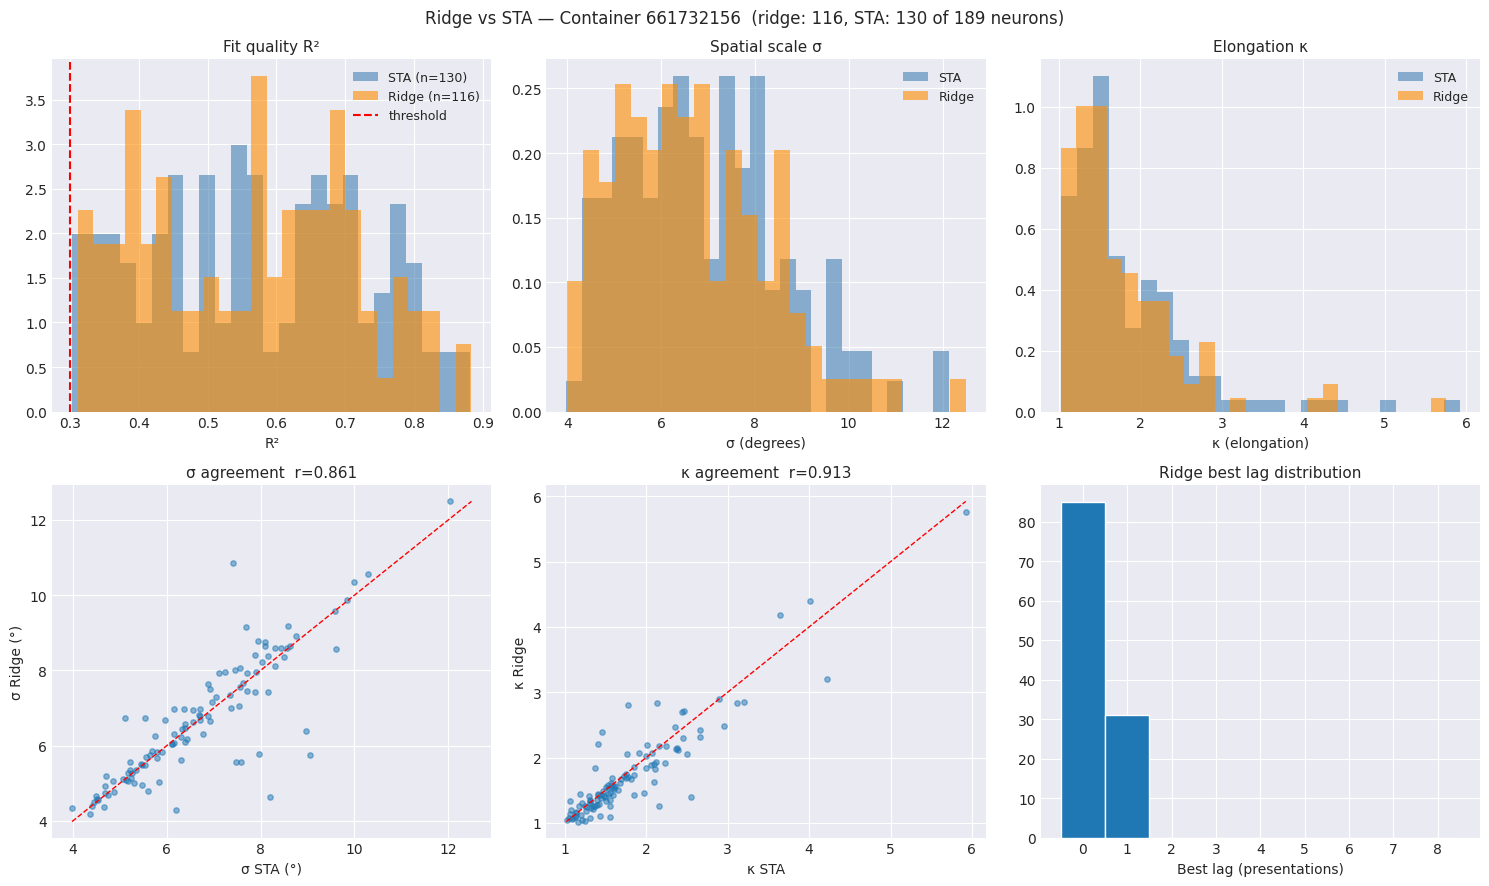

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# R² distributions
ax = axes[0, 0]
ax.hist(sta_df['r_squared'], bins=25, alpha=0.6, label=f'STA (n={len(sta_df)})',
        color='steelblue', density=True)
ax.hist(ridge_df['r_squared'], bins=25, alpha=0.6, label=f'Ridge (n={len(ridge_df)})',
        color='darkorange', density=True)
ax.axvline(QUALITY_THRESHOLD, color='red', linestyle='--', label='threshold')
ax.set_xlabel('R²', fontsize=10)
ax.set_title('Fit quality R²', fontsize=11)
ax.legend(fontsize=9)

# σ distributions
ax = axes[0, 1]
ax.hist(sta_df['sigma'].dropna(), bins=25, alpha=0.6, label='STA',
        color='steelblue', density=True)
ax.hist(ridge_df['sigma'].dropna(), bins=25, alpha=0.6, label='Ridge',
        color='darkorange', density=True)
ax.set_xlabel('σ (degrees)', fontsize=10)
ax.set_title('Spatial scale σ', fontsize=11)
ax.legend(fontsize=9)

# κ distributions
ax = axes[0, 2]
ax.hist(sta_df['kappa'].dropna(), bins=25, alpha=0.6, label='STA',
        color='steelblue', density=True)
ax.hist(ridge_df['kappa'].dropna(), bins=25, alpha=0.6, label='Ridge',
        color='darkorange', density=True)
ax.set_xlabel('κ (elongation)', fontsize=10)
ax.set_title('Elongation κ', fontsize=11)
ax.legend(fontsize=9)

# σ scatter: ridge vs STA (shared neurons)
ax = axes[1, 0]
shared = ridge_both['sigma'].dropna()
shared_sta = sta_both.loc[shared.index, 'sigma'].dropna()
shared = shared.loc[shared_sta.index]
r_s, _ = pearsonr(shared, shared_sta)
ax.scatter(shared_sta, shared, s=15, alpha=0.5)
lim = (min(shared_sta.min(), shared.min()), max(shared_sta.max(), shared.max()))
ax.plot(lim, lim, 'r--', linewidth=1)
ax.set_xlabel('σ STA (°)', fontsize=10)
ax.set_ylabel('σ Ridge (°)', fontsize=10)
ax.set_title(f'σ agreement  r={r_s:.3f}', fontsize=11)

# κ scatter: ridge vs STA
ax = axes[1, 1]
shared_k = ridge_both['kappa'].dropna()
shared_k_sta = sta_both.loc[shared_k.index, 'kappa'].dropna()
shared_k = shared_k.loc[shared_k_sta.index]
r_k, _ = pearsonr(shared_k, shared_k_sta)
ax.scatter(shared_k_sta, shared_k, s=15, alpha=0.5)
lim_k = (min(shared_k_sta.min(), shared_k.min()), max(shared_k_sta.max(), shared_k.max()))
ax.plot(lim_k, lim_k, 'r--', linewidth=1)
ax.set_xlabel('κ STA', fontsize=10)
ax.set_ylabel('κ Ridge', fontsize=10)
ax.set_title(f'κ agreement  r={r_k:.3f}', fontsize=11)

# Best lag distribution
ax = axes[1, 2]
if 'best_lag' in ridge_df.columns:
    ax.hist(ridge_df['best_lag'], bins=range(10), edgecolor='white', align='left')
    ax.set_xlabel('Best lag (presentations)', fontsize=10)
    ax.set_title('Ridge best lag distribution', fontsize=11)
    ax.set_xticks(range(9))
else:
    ax.text(0.5, 0.5, 'best_lag not in ridge_df', ha='center', va='center',
            transform=ax.transAxes)

fig.suptitle(f'Ridge vs STA — Container {CONTAINER_ID}  '
             f'(ridge: {len(ridge_df)}, STA: {len(sta_df)} of {len(cell_ids)} neurons)',
             fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_ridge_vs_sta_params.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Ridge RF gallery sorted by κ

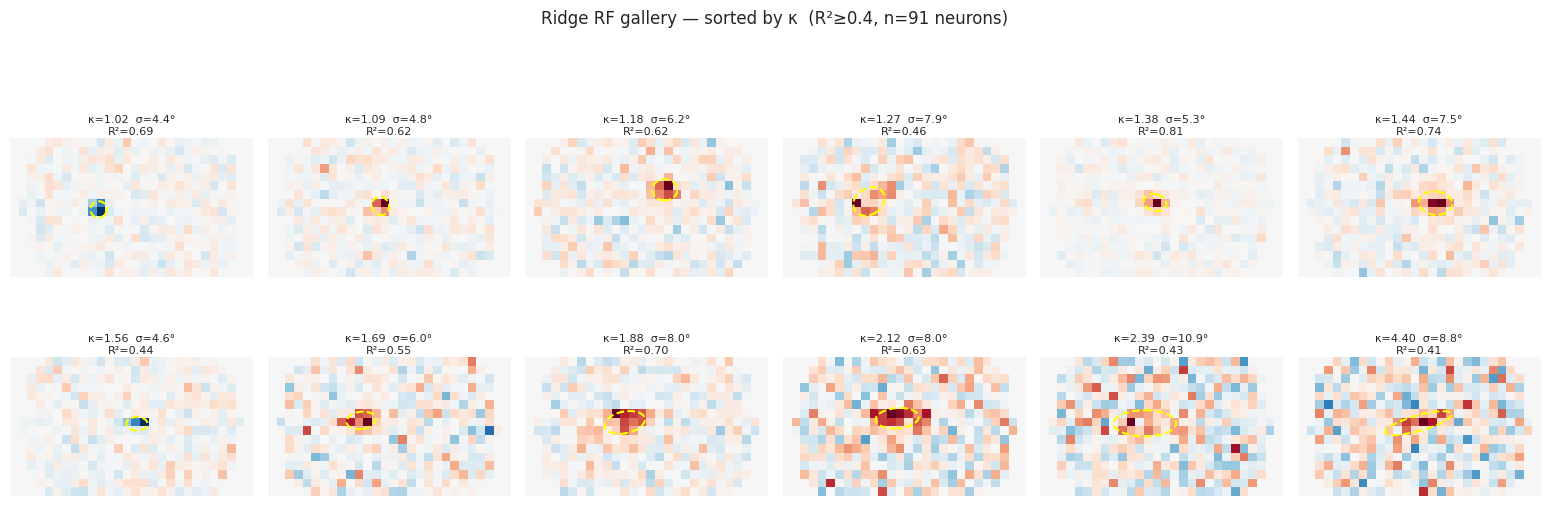

Saved: fig_ridge_gallery_kappa.png


In [13]:
N_COLS = 6
N_ROWS = 2
QUALITY_GALLERY = 0.40

clean = ridge_df.dropna(subset=['sigma', 'kappa', 'theta', 'sigma_x', 'sigma_y', 'x0', 'y0'])
clean = clean[clean['r_squared'] >= QUALITY_GALLERY].sort_values('kappa').reset_index(drop=True)

if len(clean) < 2:
    print(f'Only {len(clean)} neurons pass R²≥{QUALITY_GALLERY} — lower threshold or re-check.')
else:
    indices  = np.linspace(0, len(clean) - 1, N_COLS * N_ROWS).astype(int)
    selected = clean.iloc[indices].reset_index(drop=True)

    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 2.6, N_ROWS * 2.8))
    axes = axes.flatten()

    for ax_i, (_, row) in enumerate(selected.iterrows()):
        ax = axes[ax_i]
        try:
            ro, roff, rmeta = reconstruct_rf(dataset, int(row['cell_id']))
            rf  = ro - roff
            pix = rmeta['pixel_size_deg']
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:40], ha='center', va='center',
                    transform=ax.transAxes, fontsize=6)
            ax.axis('off')
            continue

        vmax = np.abs(rf).max()
        ax.imshow(rf, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                  origin='upper', aspect='equal')
        ell = Ellipse(xy=(row['x0']/pix, row['y0']/pix),
                      width=2*row['sigma_x']/pix, height=2*row['sigma_y']/pix,
                      angle=row['theta'],
                      edgecolor='yellow', facecolor='none', linewidth=1.5, linestyle='--')
        ax.add_patch(ell)
        ax.set_title(f"κ={row['kappa']:.2f}  σ={row['sigma']:.1f}°\nR²={row['r_squared']:.2f}",
                     fontsize=8, pad=3)
        ax.axis('off')

    fig.suptitle(f'Ridge RF gallery — sorted by κ  '
                 f'(R²≥{QUALITY_GALLERY}, n={len(clean)} neurons)',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig_ridge_gallery_kappa.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved: fig_ridge_gallery_kappa.png')

---
## 6. Summary

In [14]:
print('=' * 60)
print('RIDGE REGRESSION TEST SUMMARY')
print('=' * 60)
print(f'Container:   {CONTAINER_ID}  ({len(cell_ids)} neurons)')
print()
print(f'Yield        STA:   {len(sta_df):3d}  ({100*len(sta_df)/len(cell_ids):.1f}%)')
print(f'             Ridge: {len(ridge_df):3d}  ({100*len(ridge_df)/len(cell_ids):.1f}%)')
delta = len(ridge_df) - len(sta_df)
print(f'             Δ:     {delta:+d}')
print()
if len(ridge_df):
    print(f'Ridge σ:  mean={ridge_df["sigma"].mean():.2f}°  CV={ridge_df["sigma"].std()/ridge_df["sigma"].mean():.3f}')
    print(f'Ridge κ:  median={ridge_df["kappa"].median():.2f}  mean={ridge_df["kappa"].mean():.2f}')
    print(f'Ridge R²: mean={ridge_df["r_squared"].mean():.3f}')
if 'best_lag' in ridge_df.columns:
    print(f'Best lag: mode={int(ridge_df["best_lag"].mode()[0])}  mean={ridge_df["best_lag"].mean():.1f}')
if 'ridge_lambda' in ridge_df.columns:
    print(f'λ selected: {ridge_df["ridge_lambda"].describe().round(3).to_dict()}')
print()
print('Figures saved to outputs/rf_params/')

RIDGE REGRESSION TEST SUMMARY
Container:   661732156  (189 neurons)

Yield        STA:   130  (68.8%)
             Ridge: 116  (61.4%)
             Δ:     -14

Ridge σ:  mean=6.65°  CV=0.248
Ridge κ:  median=1.54  mean=1.76
Ridge R²: mean=0.562
Best lag: mode=0  mean=0.3
λ selected: {'count': 116.0, 'mean': 8290.115, 'std': 19059.198, 'min': 464.159, '25%': 1778.279, '50%': 3480.701, '75%': 6812.921, 'max': 100000.0}

Figures saved to outputs/rf_params/
